In [1]:
! pip install kaggle

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
! chmod 600 ~/.kaggle/kaggle.json

In [4]:
! kaggle competitions download challenges-in-representation-learning-facial-expression-recognition-challenge

100% 285M/285M [00:03<00:00, 85.2MB/s]



In [5]:
! unzip challenges-in-representation-learning-facial-expression-recognition-challenge.zip

Archive:  challenges-in-representation-learning-facial-expression-recognition-challenge.zip
  inflating: example_submission.csv  
  inflating: fer2013.tar.gz          
  inflating: icml_face_data.csv      
  inflating: test.csv                
  inflating: train.csv               


In [6]:
! pip install kaggle wandb --quiet

In [7]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import wandb

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## Data loading

In [8]:
df = pd.read_csv('icml_face_data.csv')
df.columns = df.columns.str.strip()
print(df.shape)
print(df['Usage'].value_counts())
df.head(3)

(35887, 3)
Usage
Training       28709
PublicTest      3589
PrivateTest     3589
Name: count, dtype: int64


,emotion,Usage,pixels
0,0,Training,70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...
1,0,Training,151 150 147 155 148 133 111 140 170 174 182 15...
2,2,Training,231 212 156 164 174 138 161 173 182 200 106 38...


In [9]:
EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']
PIXELS_COL  = ' pixels' if ' pixels' in df.columns else 'pixels'
EMOTION_COL = 'emotion'
USAGE_COL   = 'Usage'

class FERDataset(Dataset):
    def __init__(self, df, transform=None):
        self.labels = df[EMOTION_COL].values
        pixels = np.array(
            [np.fromstring(p, sep=' ', dtype=np.uint8) for p in df[PIXELS_COL]]
        ).reshape(-1, 48, 48)
        self.images = pixels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx][np.newaxis, :, :]
        img = torch.from_numpy(img).float() / 255.0
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label

In [10]:
MEAN, STD = 0.5071, 0.2555

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomResizedCrop(48, scale=(0.85, 1.0)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.Normalize(mean=[MEAN], std=[STD]),
])
val_transform = T.Compose([
    T.Normalize(mean=[MEAN], std=[STD]),
])

train_df = df[df[USAGE_COL] == 'Training'].reset_index(drop=True)
val_df   = df[df[USAGE_COL] == 'PublicTest'].reset_index(drop=True)

BATCH_SIZE = 64
train_ds = FERDataset(train_df, transform=train_transform)
val_ds   = FERDataset(val_df,   transform=val_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 28709 | Val: 3589


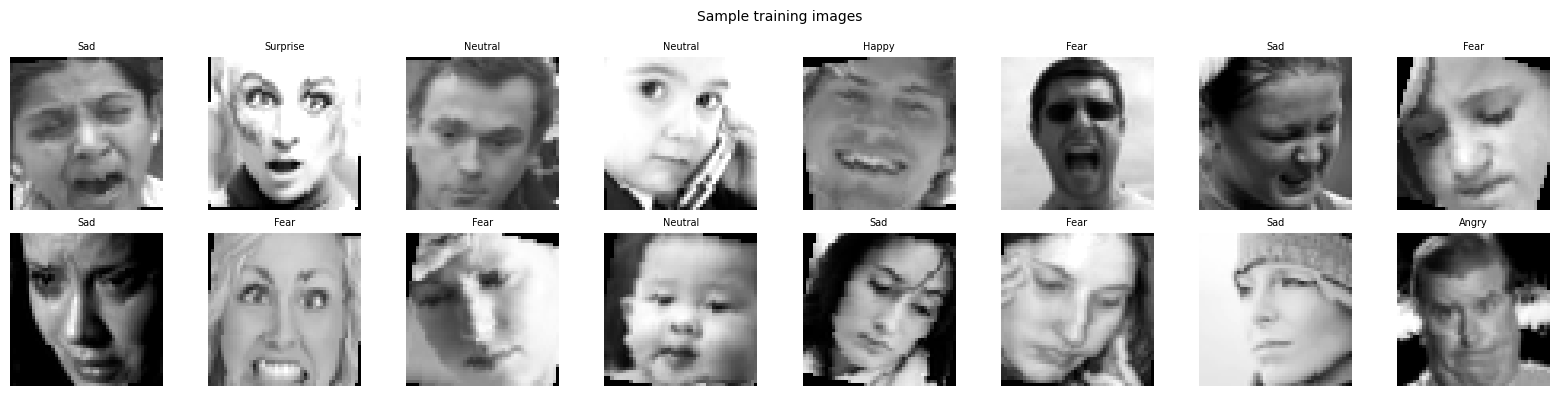

In [11]:
imgs, lbls = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i, 0].numpy(), cmap='gray')
    ax.set_title(EMOTION_LABELS[lbls[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample training images', fontsize=10)
plt.tight_layout()
plt.show()

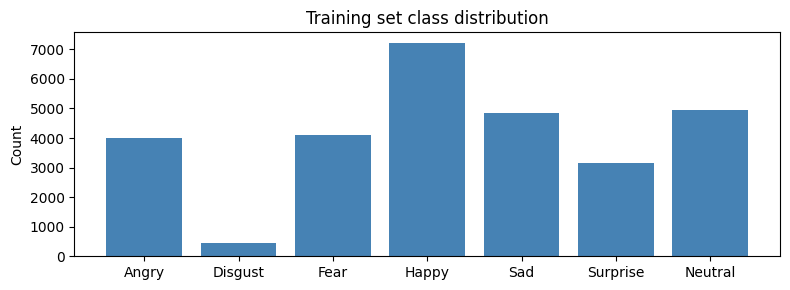

emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


In [12]:
counts = train_df[EMOTION_COL].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(EMOTION_LABELS, counts.values, color='steelblue')
ax.set_ylabel('Count')
ax.set_title('Training set class distribution')
plt.tight_layout()
plt.show()
print(counts)

## Model

In [13]:
BATCH_SIZE = 128

CONFIG = dict(
    experiment   = 'resnet_cnn_exp3_warmup_cosine',
    architecture = 'ResNetCNN_SE_5blocks',
    epochs       = 100,
    batch_size   = BATCH_SIZE,
    lr           = 1e-3,
    weight_decay = 1e-3,
    fc_dropout   = 0.6,
    se_reduction = 16,
    optimizer    = 'Adam',
    scheduler    = 'OneCycleLR',
    augmentation = 'flip+rotation15+crop+jitter',
    seed         = SEED,
)

In [14]:
class SEBlock(nn.Module):
    """Squeeze-and-Excitation: learns per-channel importance weights."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        scale = self.se(x).unsqueeze(-1).unsqueeze(-1)
        return x * scale


class ResBlock(nn.Module):
    """Residual block with optional downsampling + SE attention."""
    def __init__(self, in_ch, out_ch, stride=1, se_reduction=16):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.se = SEBlock(out_ch, reduction=se_reduction)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.conv(x)
        out = self.se(out)
        out = out + self.shortcut(x)
        return self.relu(out)


class ResNetCNN(nn.Module):
    """ResNet-style CNN with SE attention for FER-2013. Input: (B,1,48,48)"""
    def __init__(self, num_classes=7, fc_dropout=0.5, se_reduction=16):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(
            ResBlock(32,  64,  stride=2, se_reduction=se_reduction),
            ResBlock(64,  64,  stride=1, se_reduction=se_reduction),
        )
        self.layer2 = nn.Sequential(
            ResBlock(64,  128, stride=2, se_reduction=se_reduction),
            ResBlock(128, 128, stride=1, se_reduction=se_reduction),
        )
        self.layer3 = nn.Sequential(
            ResBlock(128, 256, stride=2, se_reduction=se_reduction),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(fc_dropout),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        return self.classifier(x)


model = ResNetCNN(fc_dropout=CONFIG['fc_dropout']).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'Total parameters: {total_params:,}')

ResNetCNN(
  (stem): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (se): SEBlock(
        (se): Sequential(
          (0): AdaptiveAvgPool2d(output_size=1)
          (1): Flatten(start_dim=1, end_dim=-1)
          (2): Linear(in_features=64, out_features=4, bias=False)
          (3): ReLU(inplace=True)
          (4): Linear(in_features=4, out

## Forward & backward pass checks

In [15]:
model.eval()
with torch.no_grad():
    dummy = torch.randn(8, 1, 48, 48).to(DEVICE)
    out   = model(dummy)
print(f'Output shape : {out.shape}')
print(f'Contains NaN : {torch.isnan(out).any().item()}')
print(f'Contains Inf : {torch.isinf(out).any().item()}')
assert out.shape == (8, 7)
print('Forward pass OK')

Output shape : torch.Size([8, 7])
Contains NaN : False
Contains Inf : False
Forward pass OK


In [16]:
model.train()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
_optimizer = optim.Adam(model.parameters(), lr=1e-3)
single_imgs, single_lbls = next(iter(train_loader))
single_imgs = single_imgs.to(DEVICE)
single_lbls = single_lbls.to(DEVICE)
print('Overfit on 1 batch for 50 steps:')
for step in range(50):
    _optimizer.zero_grad()
    loss = criterion(model(single_imgs), single_lbls)
    loss.backward()
    _optimizer.step()
    if (step + 1) % 10 == 0:
        print(f'  step {step+1:3d}  loss={loss.item():.4f}')
print('Backward pass OK')

Overfit on 1 batch for 50 steps:
  step  10  loss=1.1060
  step  20  loss=0.5784
  step  30  loss=0.5383
  step  40  loss=0.5082
  step  50  loss=0.5072
Backward pass OK


In [17]:
print(f"{'Parameter':<65} {'Shape':<20} {'Grad mean abs':>14}")
print('-' * 102)
dead = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if param.grad is None:
            dead.append(name)
            print(f"{name:<65} {str(tuple(param.shape)):<20} {'NO GRAD':>14}")
        else:
            print(f"{name:<65} {str(tuple(param.shape)):<20} {param.grad.abs().mean().item():>14.6f}")
if dead:
    print(f'Dead params: {dead}')
else:
    print('Gradient flow OK')
model = ResNetCNN(fc_dropout=CONFIG['fc_dropout']).to(DEVICE)

Parameter                                                         Shape                 Grad mean abs
------------------------------------------------------------------------------------------------------
stem.0.weight                                                     (32, 1, 3, 3)              0.010417
stem.1.weight                                                     (32,)                      0.001505
stem.1.bias                                                       (32,)                      0.001960
layer1.0.conv.0.weight                                            (64, 32, 3, 3)             0.000441
layer1.0.conv.1.weight                                            (64,)                      0.000457
layer1.0.conv.1.bias                                              (64,)                      0.000511
layer1.0.conv.3.weight                                            (64, 64, 3, 3)             0.000311
layer1.0.conv.4.weight                                            (64,)          

## 4 · Training

In [18]:
wandb.login()
wandb.init(
    project = 'fer2013-experiments',
    name    = CONFIG['experiment'],
    config  = CONFIG,
    tags    = ['resnet-cnn', 'baseline', 'se-block'],
)
wandb.config.update({'total_params': sum(p.numel() for p in model.parameters())})

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ntsuk22 (ntsuk22-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [19]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay'],
)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = CONFIG['lr'],
    steps_per_epoch = len(train_loader),
    epochs      = CONFIG['epochs'],
    pct_start   = 0.3,
)


def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, lbls)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == lbls).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)

    history['train_loss'].append(tr_loss)
    history['train_acc' ].append(tr_acc)
    history['val_loss'  ].append(vl_loss)
    history['val_acc'   ].append(vl_acc)

    wandb.log({
        'epoch'              : epoch,
        'train/loss'         : tr_loss,
        'train/acc'          : tr_acc,
        'val/loss'           : vl_loss,
        'val/acc'            : vl_acc,
        'train_val/loss_gap' : abs(tr_loss - vl_loss),
        'train_val/acc_gap'  : abs(tr_acc  - vl_acc),
        'lr'                 : optimizer.param_groups[0]['lr'],
    })

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), 'best_resnet_cnn.pt')

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{CONFIG["epochs"]} | train loss {tr_loss:.4f}  acc {tr_acc:.4f} | val loss {vl_loss:.4f}  acc {vl_acc:.4f}')

print(f'Best validation accuracy: {best_val_acc:.4f}')
wandb.run.summary['best_val_acc'] = best_val_acc

Epoch   1/100 | train loss 1.9528  acc 0.2095 | val loss 1.8123  acc 0.2600
Epoch   5/100 | train loss 1.8025  acc 0.2768 | val loss 1.7364  acc 0.3310
Epoch  10/100 | train loss 1.4646  acc 0.4940 | val loss 1.4202  acc 0.5152
Epoch  15/100 | train loss 1.3617  acc 0.5507 | val loss 1.3511  acc 0.5548
Epoch  20/100 | train loss 1.3279  acc 0.5682 | val loss 1.3703  acc 0.5483
Epoch  25/100 | train loss 1.3097  acc 0.5787 | val loss 1.2757  acc 0.5910
Epoch  30/100 | train loss 1.2896  acc 0.5881 | val loss 1.2778  acc 0.5946
Epoch  35/100 | train loss 1.2735  acc 0.5958 | val loss 1.2678  acc 0.5940
Epoch  40/100 | train loss 1.2656  acc 0.6000 | val loss 1.2792  acc 0.5974
Epoch  45/100 | train loss 1.2501  acc 0.6090 | val loss 1.2633  acc 0.5979
Epoch  50/100 | train loss 1.2374  acc 0.6168 | val loss 1.2465  acc 0.6099
Epoch  55/100 | train loss 1.2164  acc 0.6284 | val loss 1.2142  acc 0.6311
Epoch  60/100 | train loss 1.2034  acc 0.6336 | val loss 1.2341  acc 0.6138
Epoch  65/10

## Analysis

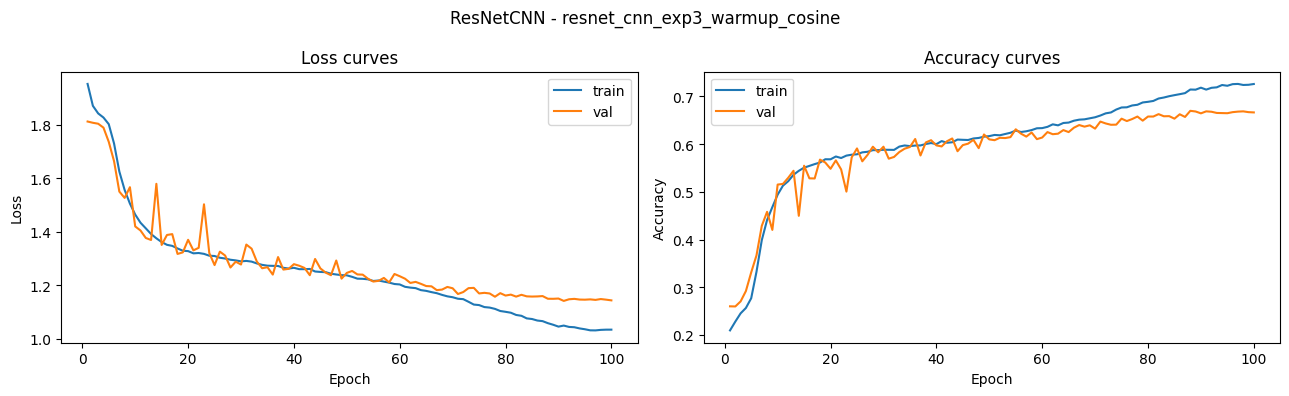

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
epochs_range = range(1, CONFIG['epochs'] + 1)
ax1.plot(epochs_range, history['train_loss'], label='train')
ax1.plot(epochs_range, history['val_loss'],   label='val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss curves'); ax1.legend()
ax2.plot(epochs_range, history['train_acc'], label='train')
ax2.plot(epochs_range, history['val_acc'],   label='val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy curves'); ax2.legend()
plt.suptitle(f"ResNetCNN - {CONFIG['experiment']}", fontsize=12)
plt.tight_layout()
wandb.log({'learning_curves': wandb.Image(fig)})
plt.show()

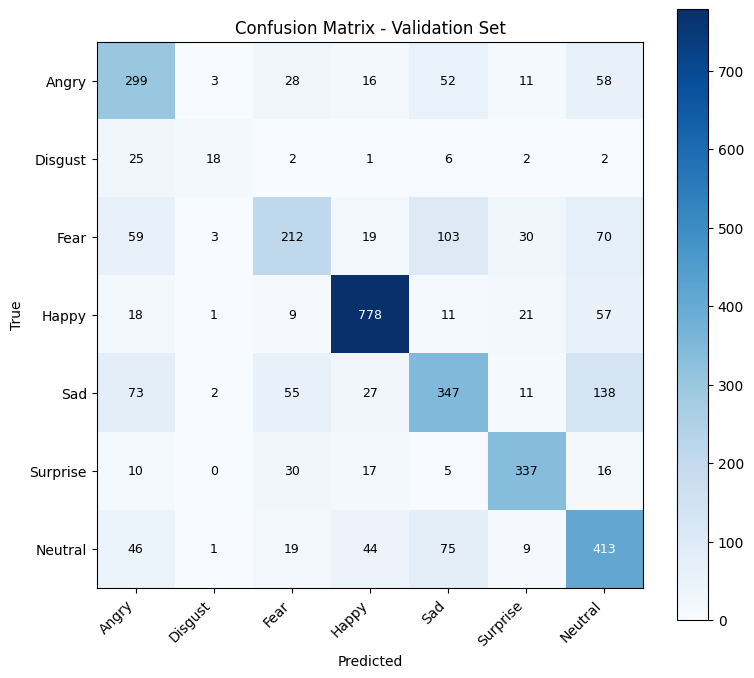

Classification report:
              precision    recall  f1-score   support

       Angry       0.56      0.64      0.60       467
     Disgust       0.64      0.32      0.43        56
        Fear       0.60      0.43      0.50       496
       Happy       0.86      0.87      0.87       895
         Sad       0.58      0.53      0.55       653
    Surprise       0.80      0.81      0.81       415
     Neutral       0.55      0.68      0.61       607

    accuracy                           0.67      3589
   macro avg       0.66      0.61      0.62      3589
weighted avg       0.67      0.67      0.67      3589



In [21]:
from sklearn.metrics import confusion_matrix, classification_report
model.load_state_dict(torch.load('best_resnet_cnn.pt', map_location=DEVICE))
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, lbls in val_loader:
        imgs  = imgs.to(DEVICE)
        preds = model(imgs).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.numpy())
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(7)); ax.set_xticklabels(EMOTION_LABELS, rotation=45, ha='right')
ax.set_yticks(range(7)); ax.set_yticklabels(EMOTION_LABELS)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Validation Set')
for i in range(7):
    for j in range(7):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=9)
plt.tight_layout()
wandb.log({'confusion_matrix': wandb.Image(fig)})
plt.show()
print('Classification report:')
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS))

In [22]:
from sklearn.metrics import classification_report
report = classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, output_dict=True)
table_data = [
    [e, round(report[e]['precision'],3), round(report[e]['recall'],3),
     round(report[e]['f1-score'],3), int(report[e]['support'])]
    for e in EMOTION_LABELS
]
wandb.log({'per_class_metrics': wandb.Table(
    columns=['Emotion','Precision','Recall','F1-score','Support'],
    data=table_data,
)})

final_train_acc = history['train_acc'][-1]
final_val_acc   = history['val_acc'][-1]
gap             = final_train_acc - final_val_acc

print('=' * 55)
print(f'  Final train accuracy : {final_train_acc:.4f}')
print(f'  Final val   accuracy : {final_val_acc:.4f}')
print(f'  Train-val gap        : {gap:.4f}')
print('=' * 55)

if final_train_acc < 0.50:
    diagnosis = 'UNDERFITTING - model lacks capacity.'
elif gap > 0.15:
    diagnosis = 'OVERFITTING - large train/val gap. Increase regularization.'
elif gap < 0.05 and final_val_acc < 0.60:
    diagnosis = 'UNDERFITTING with low variance - increase depth or width.'
else:
    diagnosis = 'Reasonable fit - continue with hyperparameter optimization.'

print(f'  Diagnosis: {diagnosis}')

wandb.run.summary['final_train_acc'] = final_train_acc
wandb.run.summary['final_val_acc']   = final_val_acc
wandb.run.summary['train_val_gap']   = gap
wandb.run.summary['diagnosis']       = diagnosis
wandb.finish()

  Final train accuracy : 0.7260
  Final val   accuracy : 0.6665
  Train-val gap        : 0.0596
  Diagnosis: Reasonable fit - continue with hyperparameter optimization.


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███
lr,▁▂▂▃▃▄▅▆▆▆▇▇████████▇▇▇▆▆▆▆▅▅▄▄▃▃▃▂▁▁▁▁▁
train/acc,▁▄▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇██████████
train/loss,█▇▇▆▆▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
train_val/acc_gap,▄▅▅▇▁▁▄▂▂▄▁▂▂▂▃▁▃▁▁▂▂▃▂▁▁▃▃▂▃▂▄▄▅▅▆▆▇███
train_val/loss_gap,▆▂▃▄▃▂█▁▂▂▇▁▂▂▁▁▂▂▁▁▁▂▂▁▁▂▂▂▂▂▃▂▃▃▃▄▄▅▅▅
val/acc,▁▃▄▅▆▆▆▆▅▇▇▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████████
val/loss,█▆▅▄▄▃▆▄▃▃▅▃▂▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁
best_val_acc,0.66982
diagnosis,Reasonable fit - con...
epoch,100
